In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
import warnings
warnings.filterwarnings('ignore')



df_notifications = pd.read_gbq(
    'SELECT * FROM `callcenter-439216.neobank.notifcations`',
    project_id='callcenter-439216' 

)

df_users = pd.read_gbq(
    'SELECT * FROM `callcenter-439216.neobank.users`',
    project_id='callcenter-439216' 

)

df_transaction = pd.read_gbq(
    'SELECT * FROM `callcenter-439216.neobank.transactions`',
    project_id='callcenter-439216' 

)

notif_user = pd.merge(
  df_notifications,
  df_users,
  on='user_id'  
)

all_data = pd.merge(
  df_transaction,
  notif_user,
  on='user_id'
)

In [ ]:
The neo project is all about organizing the future upcoming notifications, defining anomalies and churn along with a strategy based on each clustered category

In [2]:
notif_user = pd.merge(
  df_notifications,
  df_users,
  on='user_id'  
)

all_data = pd.merge(
  df_transaction,
  notif_user,
  on='user_id'
)

df_transaction.rename(columns={
  'created_date' : 'transaction_date'
}, inplace=True)

Data Cleaning and Preparation : 

We prepare the data for time series analysis by Converting the created_date column to datetime format.

=== BASIC DATA INSPECTION ===
Transaction table shape: (2740075, 12)
Columns: ['transaction_id', 'transactions_type', 'transactions_currency', 'amount_usd', 'transactions_state', 'ea_cardholderpresence', 'ea_merchant_mcc', 'ea_merchant_city', 'ea_merchant_country', 'direction', 'user_id', 'transaction_date']

First 10 transactions:
        transaction_id transactions_type transactions_currency  amount_usd  \
0      transaction_505             TOPUP                   AED      298.62   
1  transaction_1755379          EXCHANGE                   AED        3.51   
2     transaction_1667          EXCHANGE                   AED        0.05   
3     transaction_1429          EXCHANGE                   AED       24.14   
4      transaction_345          EXCHANGE                   AED        0.21   
5       transaction_95          EXCHANGE                   AED        0.39   
6  transaction_1755481          EXCHANGE                   AED        0.21   
7    transaction_17295          EXCHANGE  

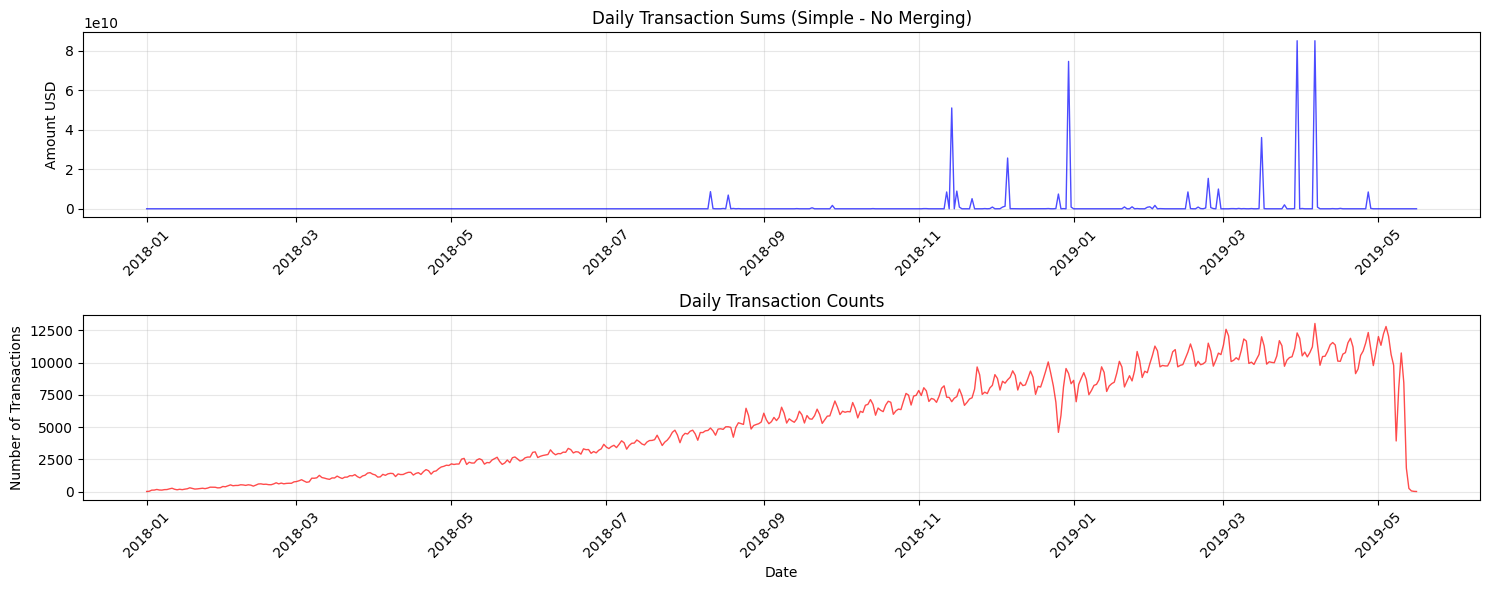


Prophet-ready data:
Shape: (501, 2)
Date range: 2018-01-01 00:00:00 to 2019-05-16 00:00:00
Y range: 0.64 to 85,107,388,903.12

Sample Prophet data:
          ds        y
0 2018-01-01    17.87
1 2018-01-02   200.34
2 2018-01-03  2477.49
3 2018-01-04  6986.23
4 2018-01-05  4767.99
            ds          y
496 2019-05-12  149949.70
497 2019-05-13   13637.25
498 2019-05-14    1814.64
499 2019-05-15     290.11
500 2019-05-16       0.64

=== RECOMMENDATION ===
Use 'prophet_data' for your Prophet model instead of the merged data!


In [ ]:

print("data insecption")

print(f"Transaction table shape: {df_transaction.shape}")
print(f"Columns: {df_transaction.columns.tolist()}")

# Show actual raw data
print(f"\nFirst 10 transactions:")
print(df_transaction.head(10))

print(f"\nAmount column detailed stats:")
print(df_transaction['amount_usd'].describe())

# Check data types
print(f"\nData types:")
print(df_transaction.dtypes)


# checking if there's any dates in the dataframe by addressing "date" & "time"
date_cols = [col for col in df_transaction.columns if 'date' in col.lower() or 'time' in col.lower()]
print(f"\nDate columns found: {date_cols}")


#if we found any col with the previous declared condition then : 
if date_cols:
    # We found one "transaction_date" then we want to display the first 10
    date_col = date_cols[0]

    #always [0] or [1] means the indexing in this case, for example if we have many cols in the df.columns we access them with the indexing
    #the only col found is transaction_date
    
    print(f"\nDate column '{date_col}' sample:")
    print(df_transaction[date_col].head(10))
    
    # Convert to datetime and check range
    df_transaction['temp_date'] = pd.to_datetime(df_transaction[date_col])
    print(f"Date range: {df_transaction['temp_date'].min()} to {df_transaction['temp_date'].max()}")
    
    # Count transactions per day
    daily_counts = df_transaction.groupby(df_transaction['temp_date'].dt.date).size()
    print(f"\nDaily transaction counts:")
    print(f"Min daily transactions: {daily_counts.min()}")
    print(f"Max daily transactions: {daily_counts.max()}")
    print(f"Average daily transactions: {daily_counts.mean():.1f}")
    print(f"Total unique days: {len(daily_counts)}")

print("\nSIMPLE DAILY AGGREGATION (NO MERGING)")

simple_data = df_transaction.copy()

# Find the correct date column
if 'created_date' in simple_data.columns:
    date_col = 'created_date'
elif 'transaction_date' in simple_data.columns:
    date_col = 'transaction_date'
else:
    date_col = date_cols[0] if date_cols else None

print(f"Using date column: {date_col}")

if date_col:
    simple_data['date'] = pd.to_datetime(simple_data[date_col]).dt.date
    
    # Simple daily sum
    daily_simple = simple_data.groupby('date')['amount_usd'].agg(['sum', 'count', 'mean']).reset_index()
    daily_simple['date'] = pd.to_datetime(daily_simple['date'])
    
    print(f"\nDaily aggregation shape: {daily_simple.shape}")
    print(f"Sample daily data:")
    print(daily_simple.head())
    
    print(f"\nDaily sum statistics:")
    print(daily_simple['sum'].describe())
    
    # Check for zero or missing days
    zero_days = (daily_simple['sum'] == 0).sum()
    print(f"Days with zero transactions: {zero_days}")
    
    # Plot the simple data
    plt.figure(figsize=(15, 6))
    plt.subplot(2, 1, 1)
    plt.plot(daily_simple['date'], daily_simple['sum'], alpha=0.7, linewidth=1, color='blue')
    plt.title('Daily Transaction Sums (Simple - No Merging)')
    plt.ylabel('Amount USD')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.plot(daily_simple['date'], daily_simple['count'], alpha=0.7, linewidth=1, color='red')
    plt.title('Daily Transaction Counts')
    plt.ylabel('Number of Transactions')
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Prepare for Prophet format
    prophet_data = daily_simple[['date', 'sum']].copy()
    prophet_data.columns = ['ds', 'y']
    
    print(f"\nProphet-ready data:")
    print(f"Shape: {prophet_data.shape}")
    print(f"Date range: {prophet_data['ds'].min()} to {prophet_data['ds'].max()}")
    print(f"Y range: {prophet_data['y'].min():,.2f} to {prophet_data['y'].max():,.2f}")
    
    print(f"\nSample Prophet data:")
    print(prophet_data.head())
    print(prophet_data.tail())
    
else:
    print("ERROR: No date column found!")

Train Prophet Model :

checked basic stats like date range and transaction amounts, and detect outliers using the IQR method, therefore set up Prophet with daily, weekly, and yearly seasonality (multiplicative mode) and fit it on the training data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import numpy as np

# Cell 1: Use the Clean Prophet Data
# Using prophet_data from the debugging step (instead of merged data)
daily_data = prophet_data.copy()

print(f"Clean data shape: {daily_data.shape}")
print(f"Date range: {daily_data['ds'].min()} to {daily_data['ds'].max()}")
print(f"Amount range: ${daily_data['y'].min():,.2f} to ${daily_data['y'].max():,.2f}")
print(f"Mean daily amount: ${daily_data['y'].mean():,.2f}")
print(f"Median daily amount: ${daily_data['y'].median():,.2f}")

# checking the possible anomlies, data needs to be pre processed 
Q1 = daily_data['y'].quantile(0.25)
Q3 = daily_data['y'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold =  Q3 + 1.5 * IQR

print(f"Outlier threshold: ${outlier_threshold:,.2f}")
outliers = daily_data[daily_data['y'] > outlier_threshold]
print(f"Number of outliers: {len(outliers)}")

#Train, Test Split
train_size = int(len(daily_data) * 0.8)
train_data = daily_data[:train_size].copy()
test_data = daily_data[train_size:].copy()

print(f"Training data: {len(train_data)} days")
print(f"Testing data: {len(test_data)} days")
print(f"Training date range: {train_data['ds'].min()} to {train_data['ds'].max()}")
print(f"Test date range: {test_data['ds'].min()} to {test_data['ds'].max()}")

# Cell 3: Prophet Model Training
print("\nTRAINING PROPHET MODEL")

# Initialize and fit Prophet model
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='multiplicative',  # Changed from multiplicative
    changepoint_prior_scale=0.05,
    interval_width=0.8
)

prophet_model.fit(train_data)
print("Prophet model training completed!")

# Make Predictions
# Create future dataframe for predictions
future_periods = len(test_data)
future = prophet_model.make_future_dataframe(periods=future_periods)

# Make predictions
prophet_forecast = prophet_model.predict(future)

print(f"Forecast shape: {prophet_forecast.shape}")
print(f"Forecast columns: {prophet_forecast.columns.tolist()}")

21:54:44 - cmdstanpy - INFO - Chain [1] start processing
21:54:44 - cmdstanpy - INFO - Chain [1] done processing


Clean data shape: (501, 2)
Date range: 2018-01-01 00:00:00 to 2019-05-16 00:00:00
Amount range: $0.64 to $85,107,388,903.12
Mean daily amount: $931,529,719.31
Median daily amount: $341,756.68
Outlier threshold: $2,392,853.15
Number of outliers: 92
Training data: 400 days
Testing data: 101 days
Training date range: 2018-01-01 00:00:00 to 2019-02-04 00:00:00
Test date range: 2019-02-05 00:00:00 to 2019-05-16 00:00:00

=== TRAINING PROPHET MODEL ===
Prophet model training completed!
Forecast shape: (501, 22)
Forecast columns: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'daily', 'daily_lower', 'daily_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'yhat']


Future Forecast :

The model is evaluated on the test set using MAE, RMSE, and MAPE. The log transform is inverted to interpret results in actual transaction amounts and we also forecast the next 30 days and generate confidence intervals to capture uncertainty.

22:33:44 - cmdstanpy - INFO - Chain [1] start processing



=== After Aggregation & Filtering (1508,000,000) ===
(413, 2)
count    4.130000e+02
mean     4.315946e+05
std      5.743315e+05
min      2.003400e+02
25%      1.138983e+05
50%      2.664006e+05
75%      5.130089e+05
max      4.821713e+06
Name: y, dtype: float64


22:33:44 - cmdstanpy - INFO - Chain [1] done processing



=== MODEL PERFORMANCE (Log-Transformed) ===
MAE: $575,756.86
RMSE: $653,086.59
MAPE: 94.06%

=== 30-DAY FUTURE FORECAST ===
            ds        yhat  yhat_lower  yhat_upper
330 2019-01-08   850410.07   465487.46  1545880.62
331 2019-01-09  1177251.91   632259.88  2136789.08
332 2019-01-10  1285913.54   662532.19  2341868.32
333 2019-01-11  1253504.08   674338.43  2341591.56
334 2019-01-12  1388859.44   746341.03  2634770.17
335 2019-01-13   944815.89   534067.73  1690255.54
336 2019-01-14   856131.97   455375.92  1558156.98
337 2019-01-15  1148609.61   612407.88  2060674.87
338 2019-01-16  1529781.51   856191.59  2926791.77
339 2019-01-17  1602343.66   886388.17  2986618.48
340 2019-01-18  1494099.40   794554.83  2792882.23
341 2019-01-19  1580918.02   809276.91  2906418.51
342 2019-01-20  1026216.36   554551.36  1945297.28
343 2019-01-21   887274.41   477400.07  1662880.23
344 2019-01-22  1136629.91   624075.55  2054026.50
345 2019-01-23  1447434.49   758589.48  2779949.61
346 2019

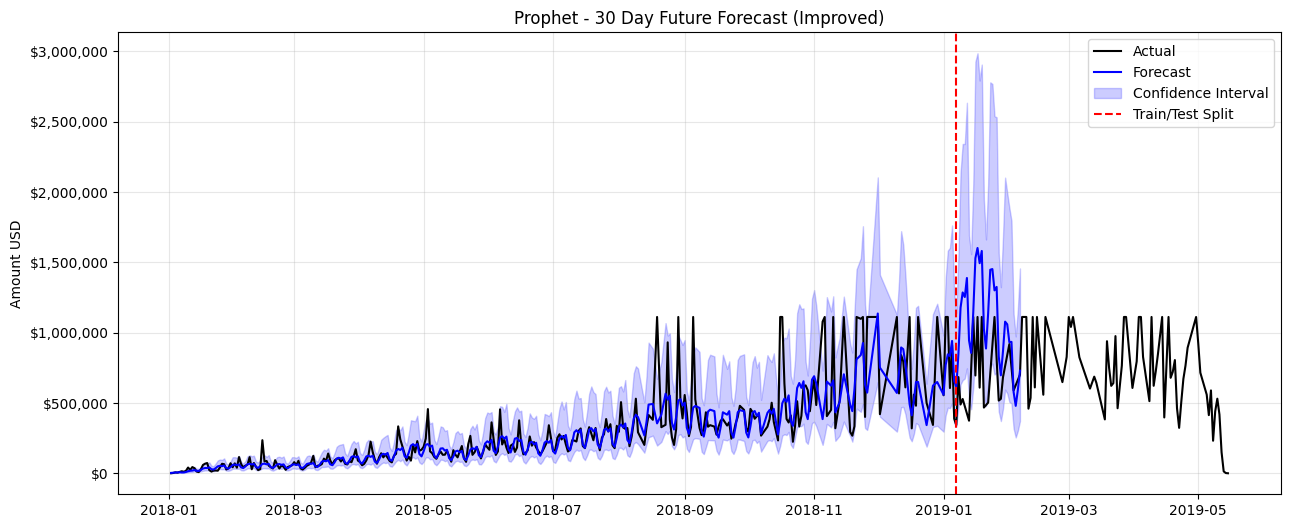

: 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Step 1: Load + Clean Data

daily_data['ds'] = pd.to_datetime(daily_data['ds'])

# Remove very small + very large values
daily_data = daily_data[(daily_data['y'] >= 150) & (daily_data['y'] < 8000000)]

# Convert ds to daily (drop hours/min/sec)
daily_data['ds'] = daily_data['ds'].dt.date

# Aggregate transactions per day (sum)
daily_data_clean = (
    daily_data.groupby('ds', as_index=False)['y'].sum()
)

# Back to datetime format for Prophet
daily_data_clean['ds'] = pd.to_datetime(daily_data_clean['ds'])

print("\n=== After Aggregation & Filtering (1508,000,000) ===")
print(daily_data_clean.shape)
print(daily_data_clean['y'].describe())

daily_data_clean['ds'] = pd.to_datetime(daily_data_clean['ds'])
#Outlier Handling (Winsorize instead of drop)

Q1 = daily_data_clean['y'].quantile(0.25)
Q3 = daily_data_clean['y'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = max(Q1 - 1.5 * IQR, 0)

# Clip instead of removing
daily_data_clean['y'] = daily_data_clean['y'].clip(lower=lower_bound, upper=upper_bound)


#Log Transform

daily_data_clean['y_log'] = np.log1p(daily_data_clean['y'])

#train and test
split_date = daily_data_clean['ds'].quantile(0.8)
train_data = daily_data_clean[daily_data_clean['ds'] <= split_date][['ds','y_log']].copy()
test_data = daily_data_clean[daily_data_clean['ds'] > split_date][['ds','y_log']].copy()

train_data.rename(columns={'y_log':'y'}, inplace=True)
test_data.rename(columns={'y_log':'y'}, inplace=True)

#prophet
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    interval_width=0.90,  # narrower intervals
    changepoint_prior_scale=0.3,  # smoother trend
    seasonality_prior_scale=5.0   # moderate seasonality
)

prophet_model.fit(train_data)


# Step 6: Predictions & Metrics

forecast = prophet_model.predict(test_data[['ds']])
y_pred = np.expm1(forecast['yhat'].values)   # invert log
y_true = np.expm1(test_data['y'].values)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("\n=== MODEL PERFORMANCE (Log-Transformed) ===")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")


# Step 7: Future Forecast

future = prophet_model.make_future_dataframe(periods=30)
forecast_future = prophet_model.predict(future)

# Invert log transform
forecast_future['yhat'] = np.expm1(forecast_future['yhat'])
forecast_future['yhat_lower'] = np.expm1(forecast_future['yhat_lower'])
forecast_future['yhat_upper'] = np.expm1(forecast_future['yhat_upper'])

latest_forecast = forecast_future.tail(30)[['ds','yhat','yhat_lower','yhat_upper']]
print("\n=== 30-DAY FUTURE FORECAST ===")
print(latest_forecast.round(2))


# Step 8: Plot

plt.figure(figsize=(15,6))
plt.plot(daily_data_clean['ds'], daily_data_clean['y'], label="Actual", color="black")
plt.plot(forecast_future['ds'], forecast_future['yhat'], label="Forecast", color="blue")
plt.fill_between(forecast_future['ds'],
                 forecast_future['yhat_lower'],
                 forecast_future['yhat_upper'],
                 color="blue", alpha=0.2, label="Confidence Interval")
plt.axvline(x=train_data['ds'].iloc[-1], color="red", linestyle="--", label="Train/Test Split")
plt.title("Prophet - 30 Day Future Forecast (Improved)")
plt.ylabel("Amount USD")
plt.legend()
plt.grid(alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.show()


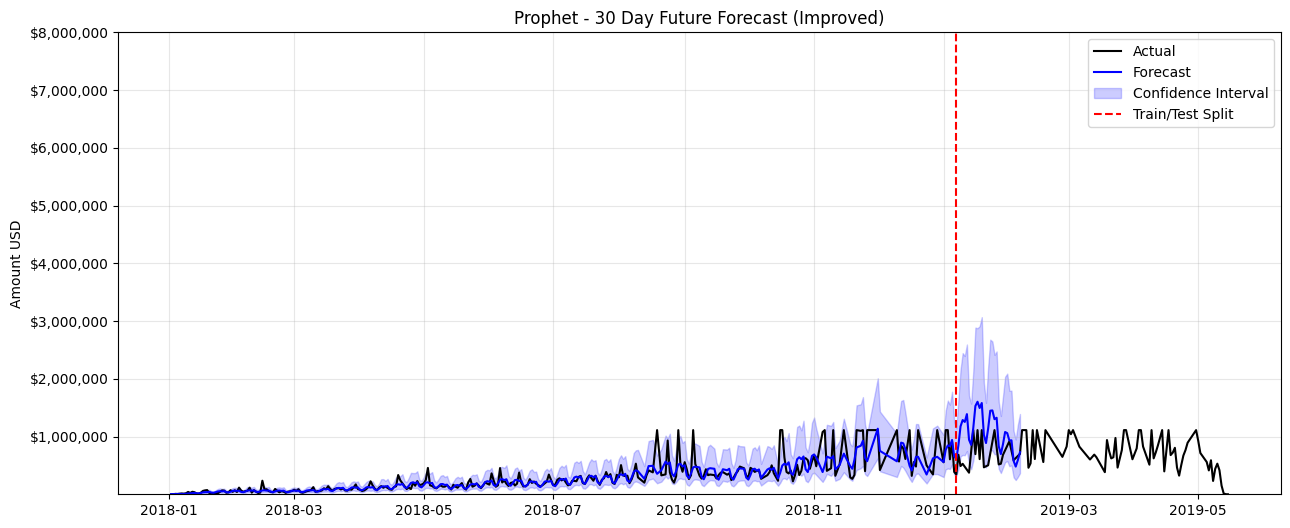

In [ ]:
# Step 8: Plot

plt.figure(figsize=(15,6))
plt.plot(daily_data_clean['ds'], daily_data_clean['y'], label="Actual", color="black")
plt.plot(forecast_future['ds'], forecast_future['yhat'], label="Forecast", color="blue")
plt.fill_between(forecast_future['ds'],
                 forecast_future['yhat_lower'],
                 forecast_future['yhat_upper'],
                 color="blue", alpha=0.2, label="Confidence Interval")
plt.axvline(x=train_data['ds'].iloc[-1], color="red", linestyle="--", label="Train/Test Split")

plt.title("Prophet - 30 Day Future Forecast (Improved)")
plt.ylabel("Amount USD")
plt.legend()
plt.grid(alpha=0.3)

# Format currency
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# >>> FIXED AXIS LIMITS <<<
plt.ylim(500, 8000000)

plt.show()



=== 30-DAY FUTURE FORECAST (Clean Data) ===
            ds        yhat  yhat_lower  yhat_upper
457 2019-05-16  6549143.83  4173625.39  9178455.58
458 2019-05-17  6170095.86  3668864.96  8827998.13
459 2019-05-18  6297079.56  3851170.69  8767868.92
460 2019-05-19  5517252.92  3036586.70  8105911.94
461 2019-05-20  5590472.39  2911994.96  8071383.95
462 2019-05-21  6208669.94  3831451.62  8719572.78
463 2019-05-22  6537532.00  3841424.68  9120680.37
464 2019-05-23  6623322.73  4225065.44  9175031.71
465 2019-05-24  6272385.89  3803545.08  8836050.00
466 2019-05-25  6425946.02  3941847.62  8906391.05
467 2019-05-26  5670526.98  3254022.56  8379672.86
468 2019-05-27  5765406.60  3242521.87  8192887.53
469 2019-05-28  6402008.70  4026544.40  9032107.06
470 2019-05-29  6745595.20  4205353.44  9249388.54
471 2019-05-30  6842100.23  4442184.79  9363605.33
472 2019-05-31  6497640.55  4078378.22  9045710.94
473 2019-06-01  6653322.37  4142681.54  9052457.73
474 2019-06-02  5895662.74  3577897.9

<Figure size 1500x600 with 0 Axes>

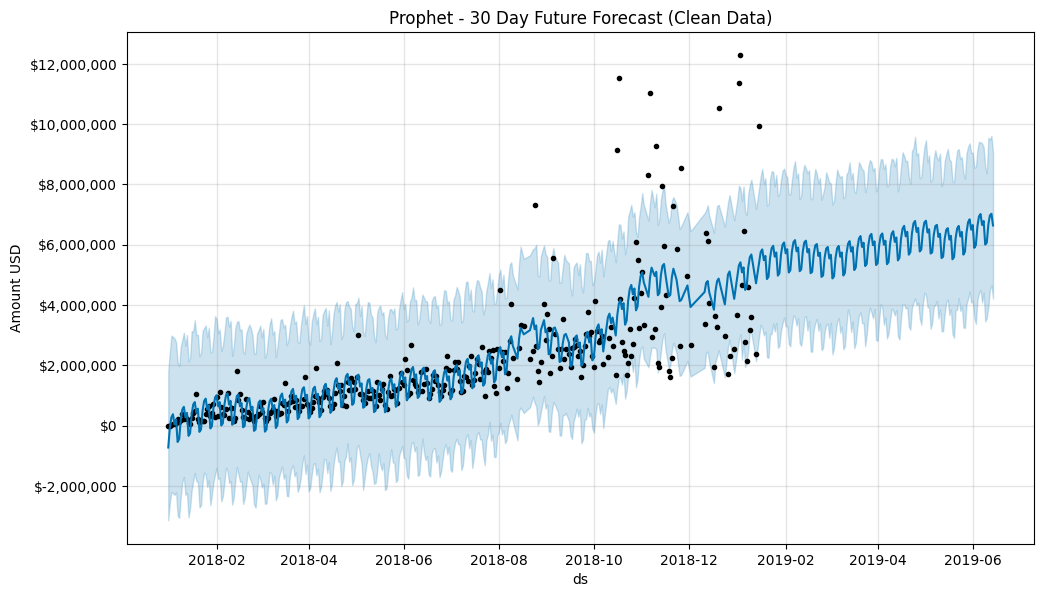

In [ ]:

# Step 7: Future Forecast

future_30_days_clean = prophet_model_clean.make_future_dataframe(periods=150)
prophet_future_forecast_clean = prophet_model_clean.predict(future_30_days_clean)

latest_forecast_clean = prophet_future_forecast_clean.tail(30)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
latest_forecast_clean['yhat'] = latest_forecast_clean['yhat'].round(2)
latest_forecast_clean['yhat_lower'] = latest_forecast_clean['yhat_lower'].round(2)
latest_forecast_clean['yhat_upper'] = latest_forecast_clean['yhat_upper'].round(2)

print("\n30-DAY FUTURE FORECAST (Clean Data)")
print(latest_forecast_clean)

# Summary

print("\nFORECAST SUMMARY")
print(f"Average daily forecast: ${latest_forecast_clean['yhat'].mean():,.2f}")
print(f"Minimum daily forecast: ${latest_forecast_clean['yhat'].min():,.2f}")
print(f"Maximum daily forecast: ${latest_forecast_clean['yhat'].max():,.2f}")
print(f"Total 30-day forecast: ${latest_forecast_clean['yhat'].sum():,.2f}")

historical_avg_clean = daily_data_clean['y'].mean()
historical_total_30_clean = historical_avg_clean * 30
print(f"\nHistorical average daily: ${historical_avg_clean:,.2f}")
print(f"Historical 30-day total: ${historical_total_30_clean:,.2f}")
print(f"Forecast vs Historical: {((latest_forecast_clean['yhat'].sum() / historical_total_30_clean - 1) * 100):+.1f}%")

# Plot forecast
plt.figure(figsize=(15, 6))
fig3 = prophet_model_clean.plot(prophet_future_forecast_clean)
plt.title('Prophet - 30 Day Future Forecast (Clean Data)')
plt.ylabel('Amount USD')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.show()



=== 30-DAY FUTURE FORECAST (Clean Data) ===
            ds        yhat  yhat_lower  yhat_upper
367 2019-02-15  5745813.21  3267388.92  8226522.00
368 2019-02-16  5856848.02  3398237.95  8268661.45
369 2019-02-17  5055069.04  2619649.90  7402086.27
370 2019-02-18  5100673.55  2557212.42  7510490.30
371 2019-02-19  5686080.72  3156612.55  8263541.37
372 2019-02-20  5977599.93  3462382.65  8579450.16
373 2019-02-21  6022239.58  3584506.24  8390731.52
374 2019-02-22  5627191.14  3129022.47  8046202.19
375 2019-02-23  5734609.50  3139893.36  8430505.26
376 2019-02-24  4932008.25  2263453.92  7453348.71
377 2019-02-25  4979689.33  2444107.34  7333760.11
378 2019-02-26  5570108.98  3083152.31  8133459.33
379 2019-02-27  5869543.28  3497680.75  8435778.81
380 2019-02-28  5924896.13  3386607.17  8397970.90
381 2019-03-01  5543184.49  3050011.74  7973268.19
382 2019-03-02  5666321.88  3288179.31  8270630.69
383 2019-03-03  4881518.72  2459416.36  7393870.77
384 2019-03-04  4948718.89  2313840.4

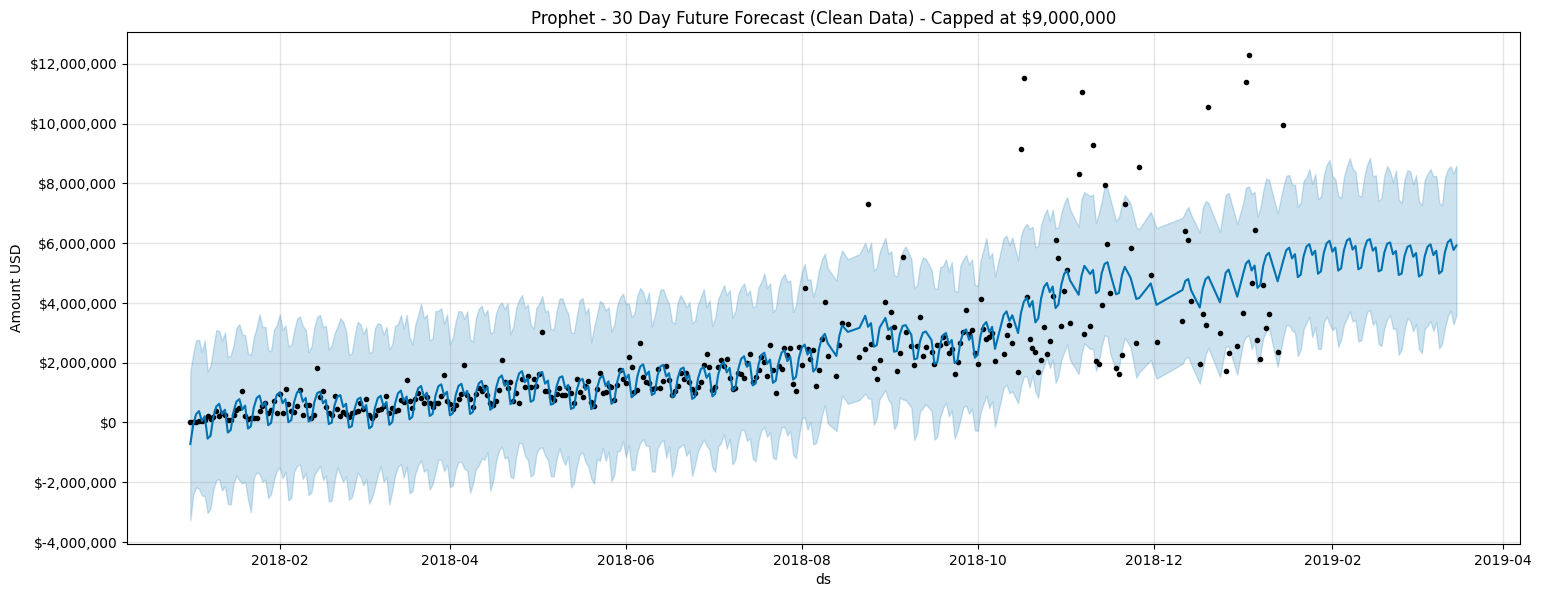

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from prophet import Prophet

# Assuming 'daily_data_clean' and 'prophet_model_clean' are already defined.

# Define the maximum display value
MAX_DISPLAY_VALUE = 9_000_000

# Step 7: Future Forecast

# Generate future dataframe for 60 periods to get the last 30 days
future_60_days_clean = prophet_model_clean.make_future_dataframe(periods=60)
prophet_future_forecast_clean = prophet_model_clean.predict(future_60_days_clean)

# Select and round the latest 30-day forecast for the summary (using the original data)
latest_forecast_clean = prophet_future_forecast_clean.tail(30)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].round(2)

print("\n30-DAY FUTURE FORECAST (Clean Data)")
print(latest_forecast_clean)

# Summary
print("\nFORECAST SUMMARY")
forecast_stats = {
    "Average daily forecast": latest_forecast_clean['yhat'].mean(),
    "Minimum daily forecast": latest_forecast_clean['yhat'].min(),
    "Maximum daily forecast": latest_forecast_clean['yhat'].max(),
    "Total 30-day forecast": latest_forecast_clean['yhat'].sum()
}
for key, value in forecast_stats.items():
    print(f"{key}: ${value:,.2f}")

# Historical comparison
historical_avg_clean = daily_data_clean['y'].mean()
historical_total_30_clean = historical_avg_clean * 30
forecast_vs_historical_percent = (latest_forecast_clean['yhat'].sum() / historical_total_30_clean - 1) * 100

print(f"\nHistorical average daily: ${historical_avg_clean:,.2f}")
print(f"Historical 30 day total: ${historical_total_30_clean:,.2f}")
print(f"Forecast vs Historical: {forecast_vs_historical_percent:+.1f}%")

# --- Prepare the data for plotting by clipping values ---
# Create a copy to avoid modifying the original forecast DataFrame
forecast_to_plot = prophet_future_forecast_clean.copy()

# Clip all relevant columns at the maximum display value
forecast_to_plot['yhat'] = forecast_to_plot['yhat'].clip(upper=MAX_DISPLAY_VALUE)
forecast_to_plot['yhat_lower'] = forecast_to_plot['yhat_lower'].clip(upper=MAX_DISPLAY_VALUE)
forecast_to_plot['yhat_upper'] = forecast_to_plot['yhat_upper'].clip(upper=MAX_DISPLAY_VALUE)

# Plot the forecast with improved aesthetics, using the clipped data
fig = prophet_model_clean.plot(forecast_to_plot, figsize=(15, 6))
plt.title(f'Prophet : 30 Day Future Forecast (Clean Data) Capped at ${MAX_DISPLAY_VALUE:,.0f}')
plt.ylabel('Amount USD')

# Directly apply formatter to the y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.show()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')



# Data preparation and cleaning
all_data.rename(columns={
  'created_date' : 'transaction_date'
}, inplace=True)


data_needed = ['transaction_date', 'amount_usd']
forecast_data = all_data[data_needed].copy()

In [ ]:
#Performance Visualization - Half-Month Detail
plt.figure(figsize=(15, 12))

# Split into half-month periods (~15 days)
chunk_size = 15
num_chunks = int(np.ceil(len(daily_data) / chunk_size))

for i in range(num_chunks):
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(daily_data))
    
    chunk_data = daily_data.iloc[start_idx:end_idx]
    chunk_forecast = prophet_forecast.iloc[start_idx:end_idx]
    
    plt.figure(figsize=(12, 5))
    plt.plot(chunk_data['ds'], chunk_data['y'], 'o', color='black', alpha=0.7, label='Actual')  # Black points = actual
    plt.plot(chunk_forecast['ds'], chunk_forecast['yhat'], '-', color='blue', label='Prophet Forecast')  # Blue line = forecast
    plt.fill_between(chunk_forecast['ds'],
                     chunk_forecast['yhat_lower'],
                     chunk_forecast['yhat_upper'],
                     alpha=0.2, color='blue', label='Confidence Interval')
    plt.title(f'Prophet Forecast - Detailed View: Days {start_idx+1} to {end_idx}')
    plt.xlabel('Date')
    plt.ylabel('Amount USD')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    plt.show()


The preprocessing 

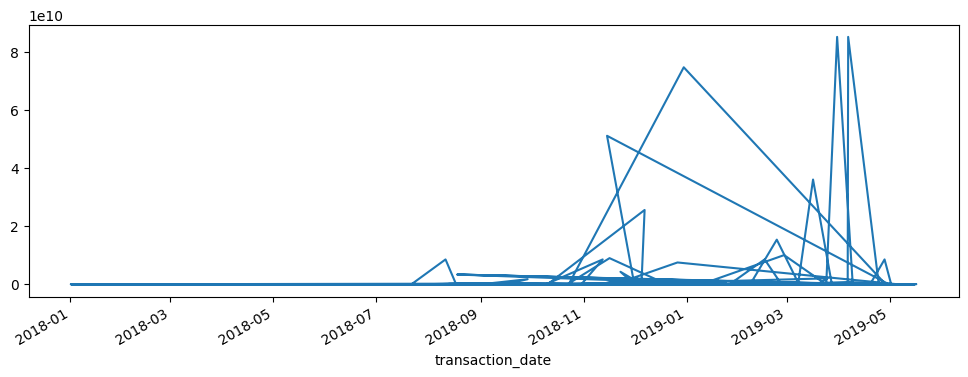

In [10]:
all_data.set_index('transaction_date')['amount_usd'].plot(kind='line', figsize=(12,4))
plt.show()


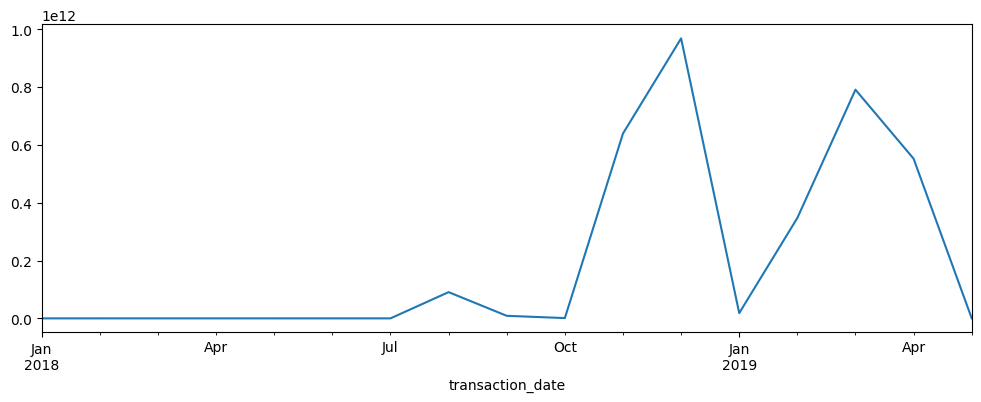

In [11]:
all_data['transaction_date_only'] = pd.to_datetime(all_data['transaction_date']).dt.date
# group by month
monthly = all_data.groupby(pd.Grouper(key='transaction_date', freq='M'))['amount_usd'].sum()

monthly.plot(figsize=(12,4))
plt.show()

In [38]:
all_data['transaction_date_only'].max()

datetime.date(2019, 5, 16)

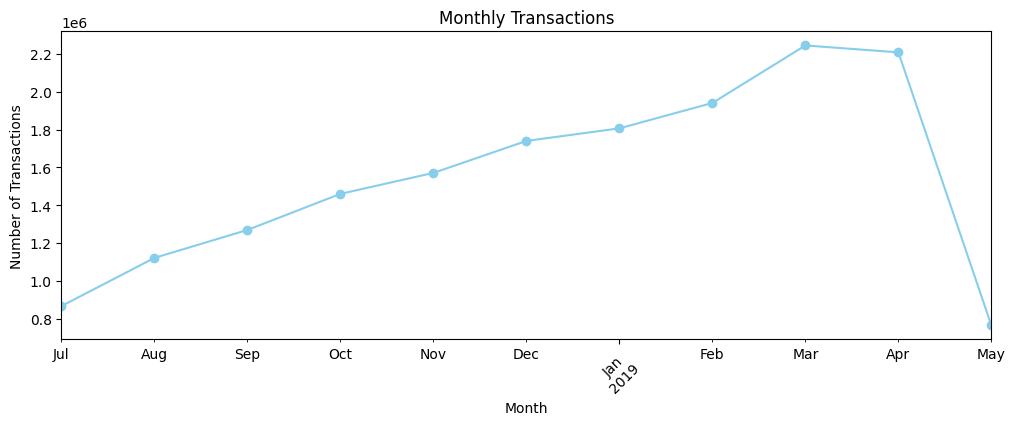

In [ ]:
import matplotlib.pyplot as plt

# Make sure transaction_date is datetime
impo_data['transaction_date'] = pd.to_datetime(impo_data['transaction_date'])

# Filter by date range
start_date = "2018-07-01"
end_date = "2019-05-16"
subset = impo_data[(impo_data['transaction_date'] >= start_date) &
                   (impo_data['transaction_date'] <= end_date)]

# Create year_month column (safe for plotting)
subset['year_month'] = subset['transaction_date'].dt.to_period('M').dt.to_timestamp()

# Group by year_month
monthly_counts = subset.groupby('year_month').size()

# Plot
monthly_counts.plot(kind='line', figsize=(12,4), marker='o', color='skyblue')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.title('Monthly Transactions')
plt.xticks(rotation=45)
plt.show()



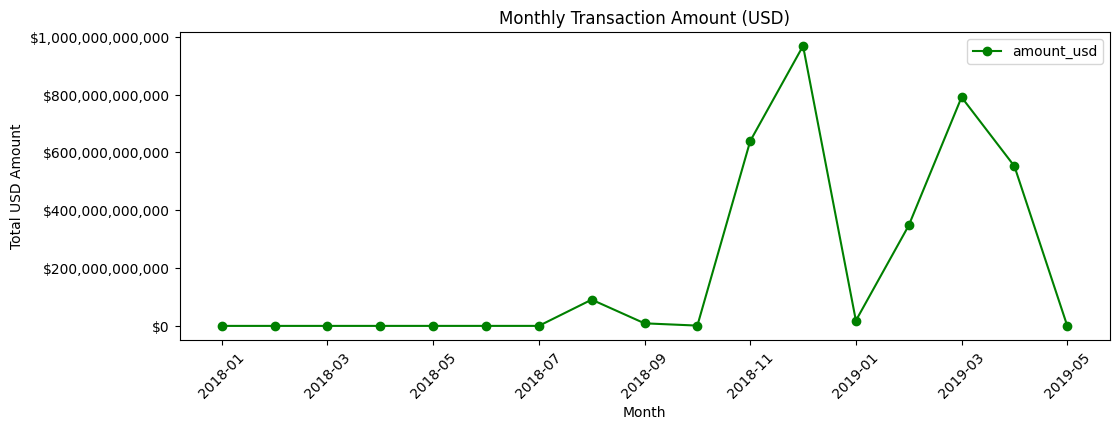

In [14]:
# Convert transaction_date to datetime if not already
all_data['transaction_date'] = pd.to_datetime(all_data['transaction_date'])

# Group by month and SUM the transaction amount
monthly_amount = (
    all_data
    .groupby(all_data['transaction_date'].dt.to_period('M'))['amount_usd']
    .sum()
    .reset_index()
)

# Convert period to string for plotting
monthly_amount['transaction_date'] = monthly_amount['transaction_date'].astype(str)

# Plot the USD amount
import matplotlib.ticker as ticker

ax = monthly_amount.plot(
    x='transaction_date',
    y='amount_usd',
    kind='line',
    figsize=(12,4),
    marker='o',
    color='green'
)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))  # format as USD with commas
plt.xlabel('Month')
plt.ylabel('Total USD Amount')
plt.title('Monthly Transaction Amount (USD)')
plt.xticks(rotation=45)
plt.show()


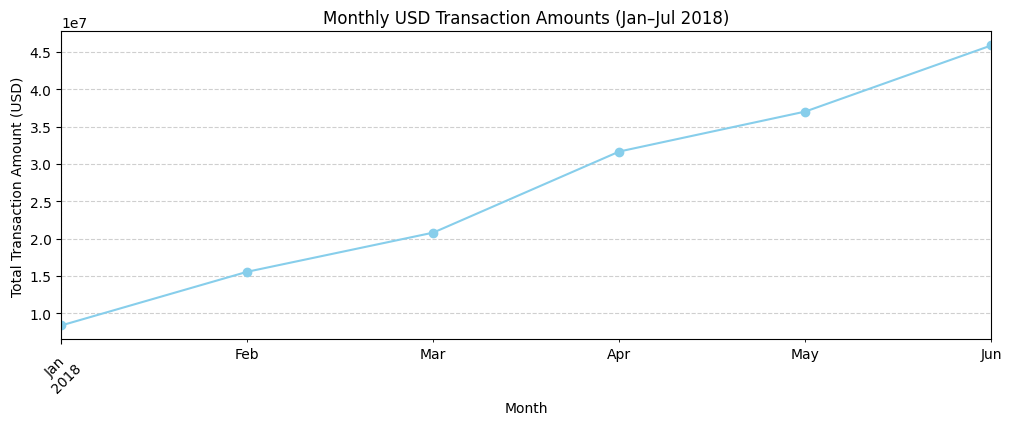

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure transaction_date is datetime and remove timezone ---
impo_data['transaction_date'] = pd.to_datetime(impo_data['transaction_date']).dt.tz_localize(None)

# --- Filter by date range ---
start_date = pd.to_datetime("2018-01-01")
end_date = pd.to_datetime("2018-07-01")

subset = impo_data[(impo_data['transaction_date'] >= start_date) &
                   (impo_data['transaction_date'] <= end_date)]

# --- Create year_month column ---
subset['year_month'] = subset['transaction_date'].dt.to_period('M').dt.to_timestamp()

# --- Group by month and sum transaction amount (USD) ---
monthly_amount = subset.groupby('year_month')['amount_usd'].sum()

# --- Plot ---
plt.figure(figsize=(12, 4))
monthly_amount.plot(kind='line', marker='o', color='skyblue')

plt.xlabel('Month')
plt.ylabel('Total Transaction Amount (USD)')
plt.title('Monthly USD Transaction Amounts (Jan–Jul 2018)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


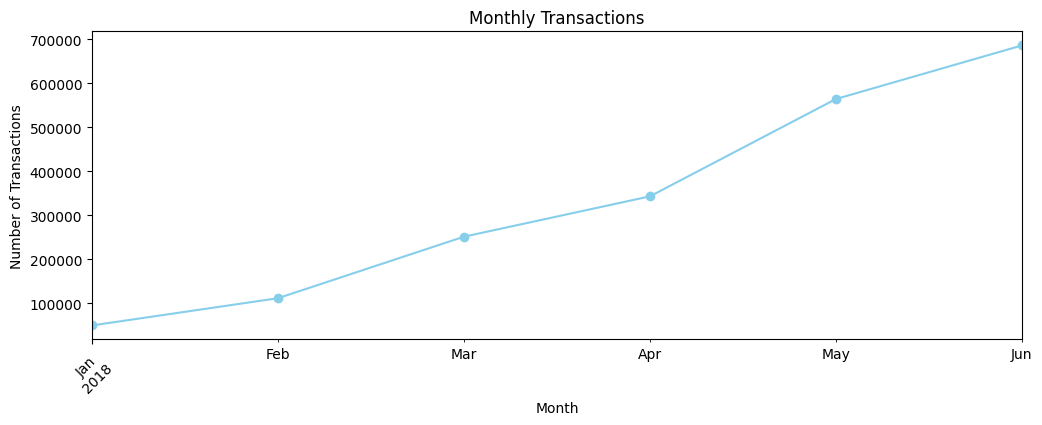

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure transaction_date is datetime
impo_data['transaction_date'] = pd.to_datetime(impo_data['transaction_date'])

# Filter by date range
start_date = "2018-01-01"
end_date = "2018-07-01"
subset = impo_data[(impo_data['transaction_date'] >= start_date) &
                   (impo_data['transaction_date'] <= end_date)]

# Create year_month column (safe for plotting)
subset['year_month'] = subset['transaction_date'].dt.to_period('M').dt.to_timestamp()

# Group by year_month
monthly_counts = subset.groupby('year_month').size()

# Plot
monthly_counts.plot(kind='line', figsize=(12,4), marker='o', color='skyblue')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.title('Monthly Transactions')
plt.xticks(rotation=45)
plt.show()



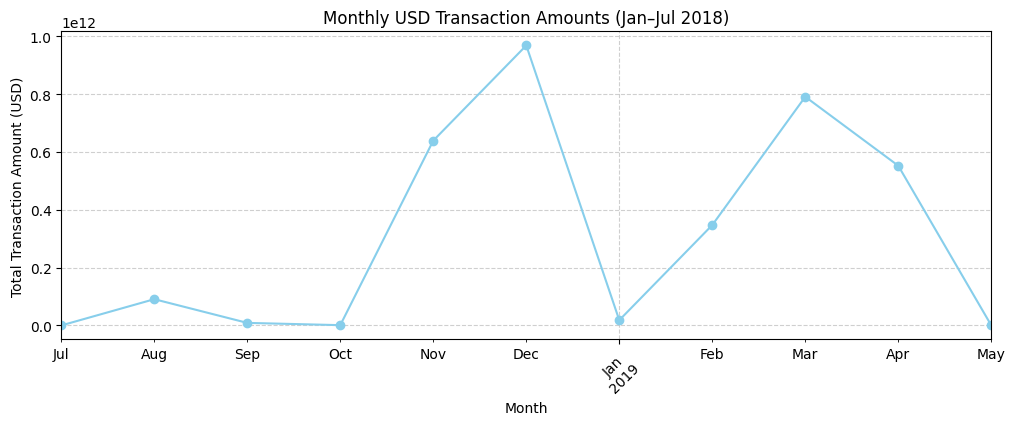

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure transaction_date is datetime and remove timezone ---
impo_data['transaction_date'] = pd.to_datetime(impo_data['transaction_date']).dt.tz_localize(None)

# --- Filter by date range ---
start_date = pd.to_datetime("2018-07-01")
end_date = pd.to_datetime("2019-05-16")

subset = impo_data[(impo_data['transaction_date'] >= start_date) &
                   (impo_data['transaction_date'] <= end_date)]

# --- Create year_month column ---
subset['year_month'] = subset['transaction_date'].dt.to_period('M').dt.to_timestamp()

# --- Group by month and sum transaction amount (USD) ---
monthly_amounts = subset.groupby('year_month')['amount_usd'].sum()

# --- Plot ---
plt.figure(figsize=(12, 4))
monthly_amounts.plot(kind='line', marker='o', color='skyblue')

plt.xlabel('Month')
plt.ylabel('Total Transaction Amount (USD)')
plt.title('Monthly USD Transaction Amounts (Jan–Jul 2018)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


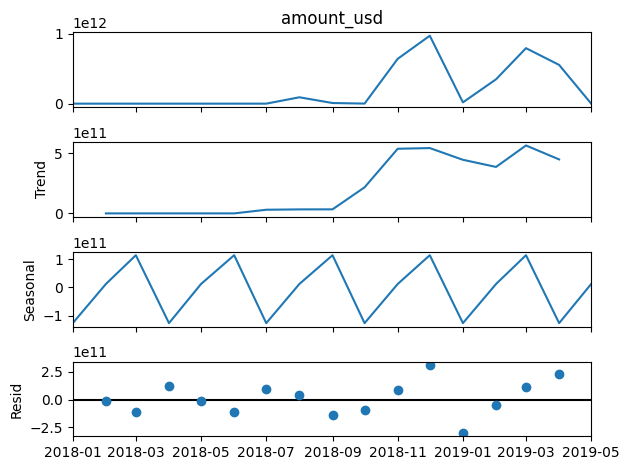

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

impo_data['year_month'] = impo_data['transaction_date'].dt.to_period('M').dt.to_timestamp()

# --- Group by month and sum transaction amount (USD) ---
monthly_amountss = impo_data.groupby('year_month')['amount_usd'].sum()

# Ensure index is datetime and sorted
monthly_amountss.index = pd.to_datetime(monthly_amountss.index)
monthly_amountss = monthly_amountss.sort_index()

# Decompose (trend + yearly seasonality)
result = seasonal_decompose(monthly_amountss, model='additive', period=3)

# Plot
result.plot()
plt.show()
